In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except AttributeError:
    pass

base_dir = '/kaggle/input/datasets/sanikamal/rock-paper-scissors-dataset/Rock-Paper-Scissors'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

2026-03-25 04:31:25.471385: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774413085.884198      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774413085.998391      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774413087.022439      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774413087.022493      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774413087.022496      55 computation_placer.cc:177] computation placer alr

In [4]:

classes = sorted(os.listdir(train_dir))
total_train = 0
for cls in classes:
    count = len(os.listdir(os.path.join(train_dir, cls)))
    total_train += count
    print(f" - Lớp {cls.upper()}: {count} ảnh")
print(f"Tổng cộng: {total_train} ảnh\n")

 - Lớp PAPER: 840 ảnh
 - Lớp ROCK: 840 ảnh
 - Lớp SCISSORS: 840 ảnh
Tổng cộng: 2520 ảnh



--- Đang load tập Training ---
Found 2016 images belonging to 3 classes.

--- Đang load tập Validation ---
Found 504 images belonging to 3 classes.

--- Đang load tập Test ---
Found 372 images belonging to 3 classes.


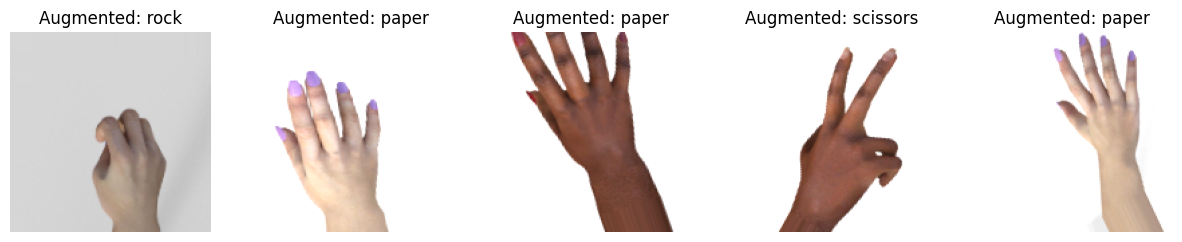

In [5]:
TARGET_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    brightness_range=[0.7, 1.3], 
    fill_mode='nearest',
    validation_split=0.2 
)

test_datagen = ImageDataGenerator(rescale=1./255)

print("--- Đang load tập Training ---")
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=TARGET_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED
)

print("\n--- Đang load tập Validation ---")
val_generator = train_datagen.flow_from_directory(
    train_dir, target_size=TARGET_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED
)

print("\n--- Đang load tập Test ---")
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=TARGET_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

plt.figure(figsize=(15, 3))
images, labels = next(train_generator)
for i in range(5):
    plt.subplot(1, 5, i+1)
    label_idx = np.argmax(labels[i])
    label_name = list(train_generator.class_indices.keys())[label_idx]
    plt.imshow(images[i])
    plt.title(f"Augmented: {label_name}")
    plt.axis('off')
plt.show()

In [6]:
model = Sequential([
    Input(shape=(150, 150, 3)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Flatten(),
    
    Dropout(0.5), 
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    
    Dropout(0.3),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    
    Dense(3, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

I0000 00:00:1774413127.349716      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774413127.356245      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,716,227 (44.69 MB)

 Trainable params: 11,713,283 (44.68 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [7]:
# TRAINING
# 0: paper, 1: rock, 2: scissors
weights_dict = {0: 2.3, 1: 1.0, 2: 1.0 }

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=8, verbose=1, restore_best_weights=True)

print("\nBắt đầu quá trình huấn luyện...")
history = model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=[reduce_lr, early_stop],
    class_weight=weights_dict,
    verbose=1
)


Bắt đầu quá trình huấn luyện...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40


I0000 00:00:1774413135.123200     160 cuda_dnn.cc:529] Loaded cuDNN version 91002


63/63 ━━━━━━━━━━━━━━━━━━━━ 58s 812ms/step - accuracy: 0.5619 - loss: 3.0966 - val_accuracy: 0.3333 - val_loss: 5.9981 - learning_rate: 0.0010
Epoch 2/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 477ms/step - accuracy: 0.8947 - loss: 2.1067 - val_accuracy: 0.3333 - val_loss: 8.0119 - learning_rate: 0.0010
Epoch 3/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 477ms/step - accuracy: 0.9382 - loss: 1.9005 - val_accuracy: 0.3413 - val_loss: 7.2023 - learning_rate: 0.0010
Epoch 4/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9402 - loss: 1.7905
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 482ms/step - accuracy: 0.9404 - loss: 1.7896 - val_accuracy: 0.3413 - val_loss: 7.5664 - learning_rate: 0.0010
Epoch 5/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 477ms/step - accuracy: 0.9684 - loss: 1.6216 - val_accuracy: 0.3532 - val_loss: 6.9102 - learning_rate: 3.0000e-04
Epoch 6/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 481ms/step - accuracy: 0.9841 - loss: 1.5239 - va

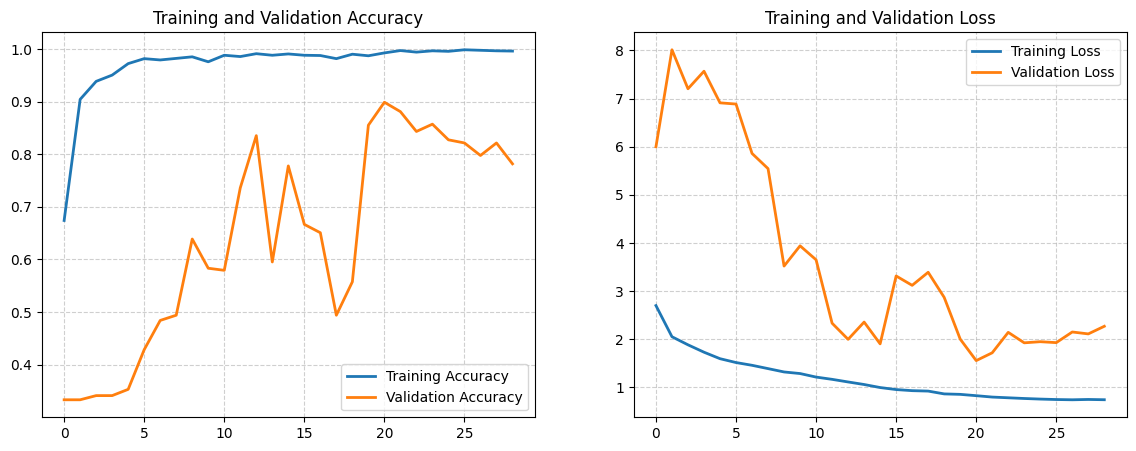

In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

#Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)

#Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

(TEST SET)
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.9732 - loss: 0.8581
Test Accuracy: 98.39%

Đã đóng gói mô hình thành công tại: /kaggle/working/rps_cnn_v2_98pct.keras

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step


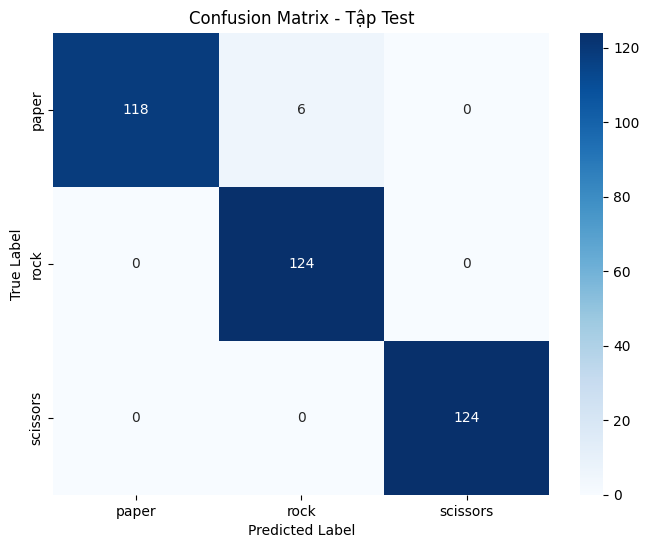

              precision    recall  f1-score   support

       paper       1.00      0.95      0.98       124
        rock       0.95      1.00      0.98       124
    scissors       1.00      1.00      1.00       124

    accuracy                           0.98       372
   macro avg       0.98      0.98      0.98       372
weighted avg       0.98      0.98      0.98       372



In [11]:
print("(TEST SET)")
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy*100:.2f}%\n")

model_name = f'rps_cnn_v2_{test_accuracy*100:.0f}pct.keras' 
model.save(f'/kaggle/working/{model_name}')
print(f"Đã đóng gói mô hình thành công tại: /kaggle/working/{model_name}\n")

predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Tập Test')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))